<a href="https://colab.research.google.com/github/jonitodev/pcvk26_8_joniyogakusuma/blob/main/P2_Tugas_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PRAKTIKUM


## 1. Koneksi antara Colab dengan Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KTM.jpg to KTM.jpg


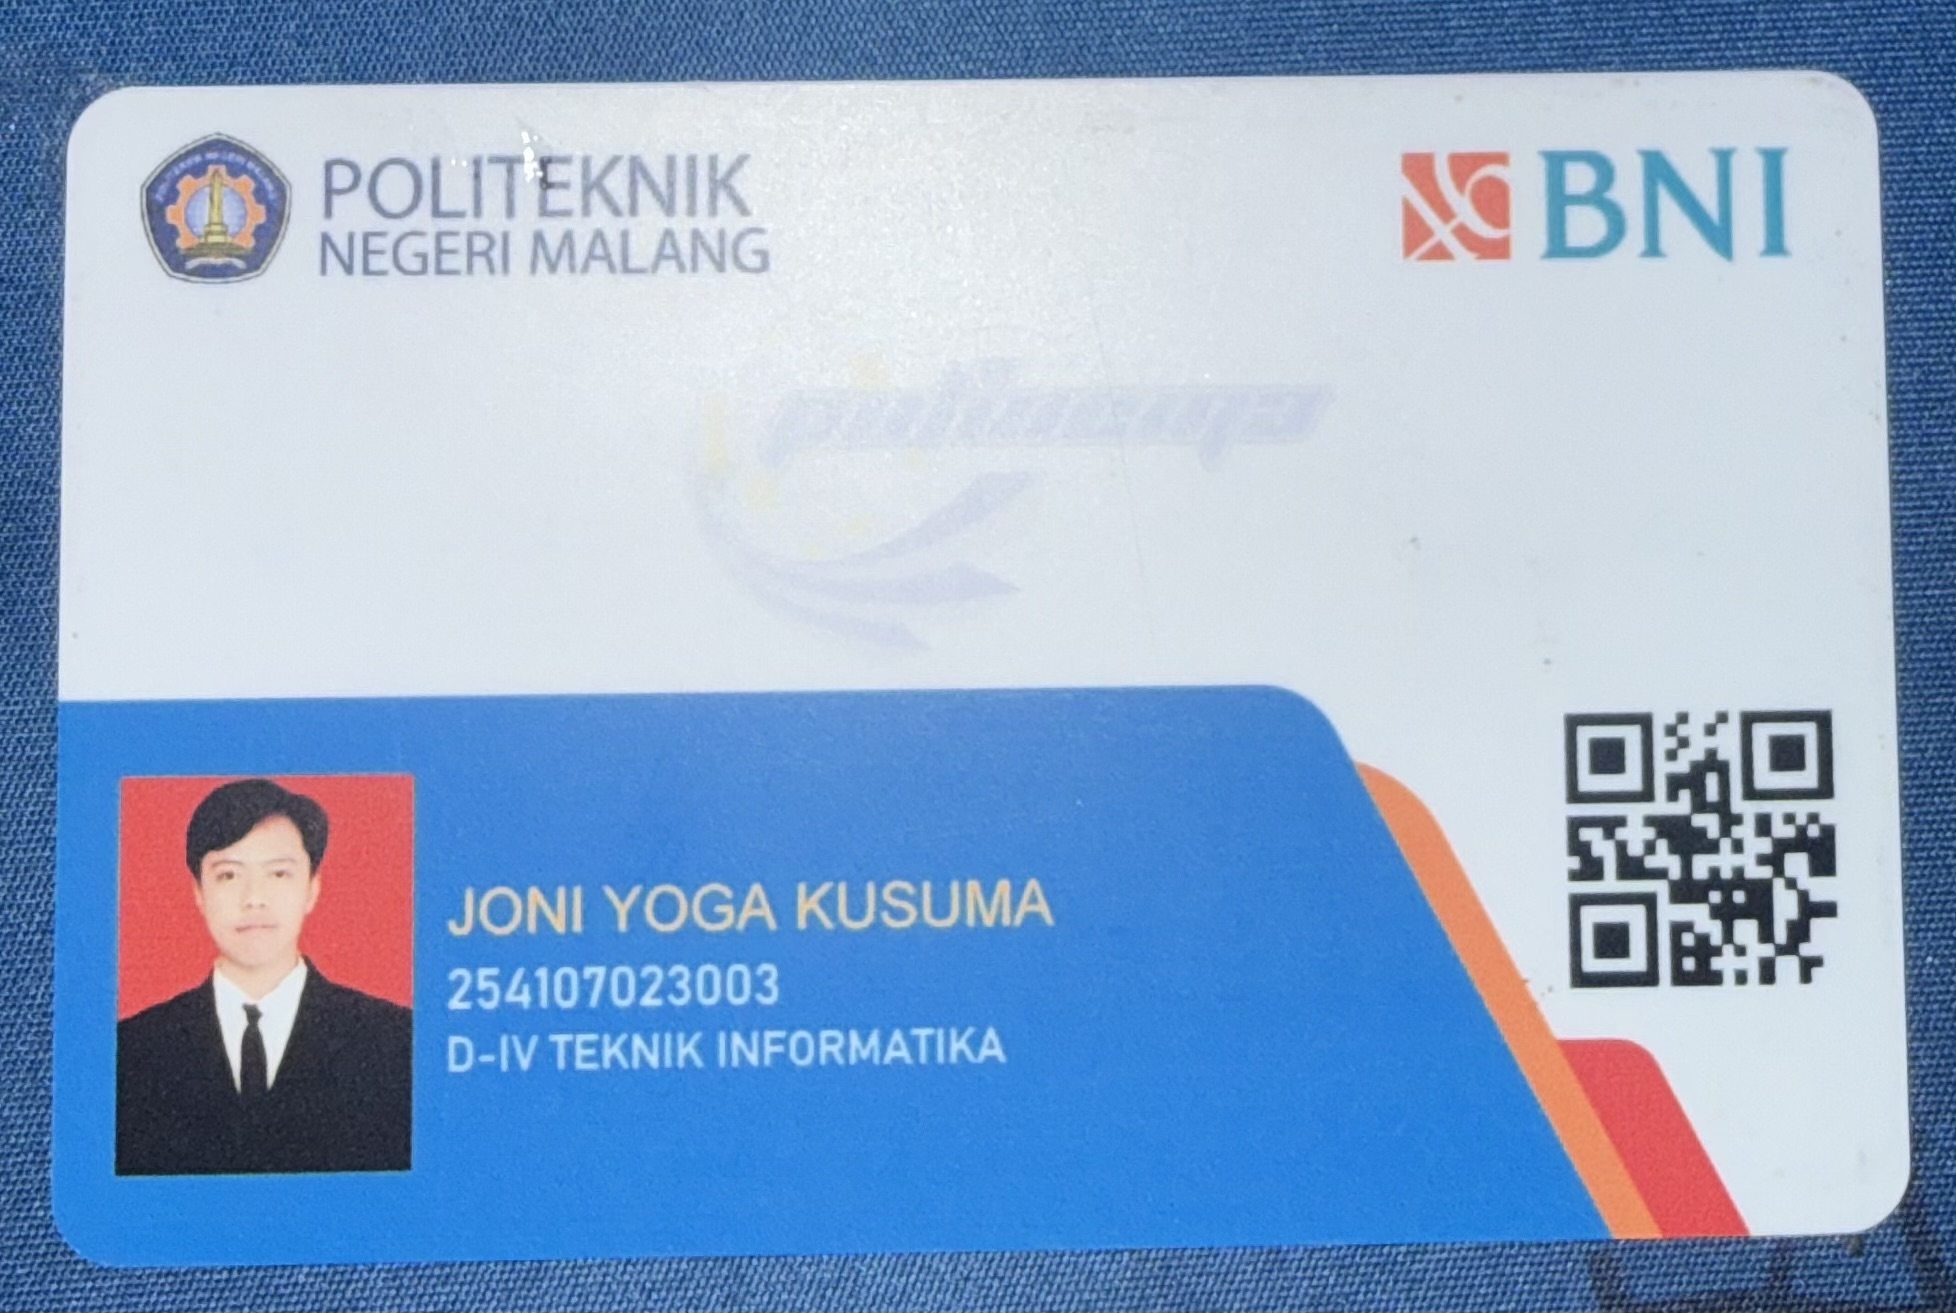

Ukuran: 1956 x 1313 piksel


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

citra = cv.imread('/content/KTM.jpg')
cv2_imshow(citra)
print("Ukuran:", citra.shape[1], "x", citra.shape[0], "piksel")


## 2. Menampilkan Gambar

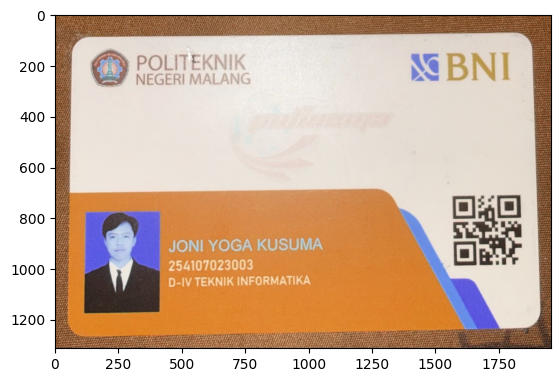

In [ ]:
citra = cv.imread('/content/KTM.jpg')
plt.imshow(citra)


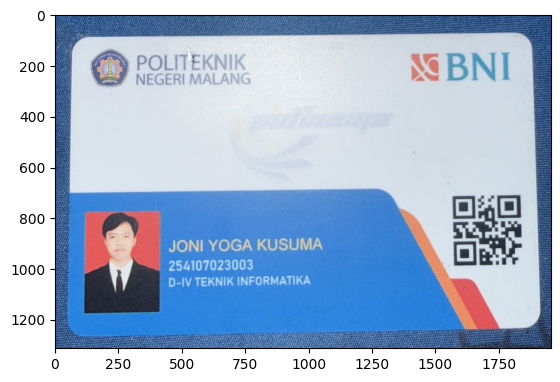

In [ ]:
citra = cv.imread('/content/KTM.jpg')
citra_rgb = citra[:, :, ::-1]
plt.imshow(citra_rgb)


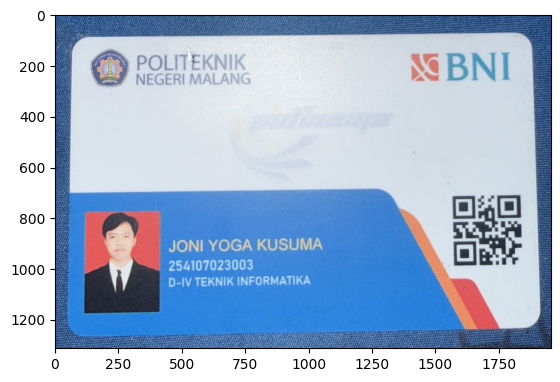

In [ ]:
citra = cv.imread('/content/KTM.jpg')
plt.imshow(citra[:, :, ::-1])
plt.show()


## 3. Menampilkan citra Grayscale

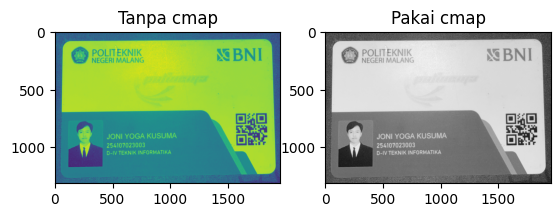

In [ ]:
abu = cv.imread('/content/KTM.jpg', 0)

fig, kolom = plt.subplots(1, 2)
kolom[0].imshow(abu)
kolom[0].set_title("Tanpa cmap")
kolom[1].imshow(abu, cmap="gray")
kolom[1].set_title("Pakai cmap")
plt.show()


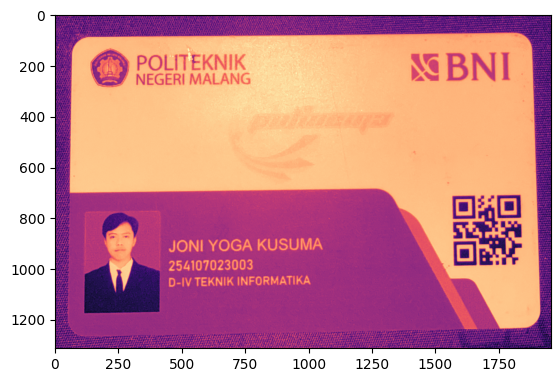

In [ ]:
plt.imshow(abu, cmap="magma")


## 4. Melakukan Resizing

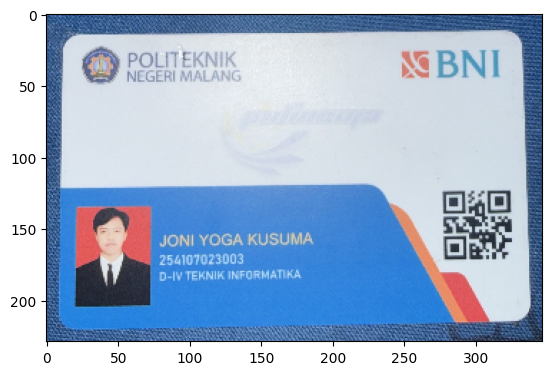

In [ ]:
citra_rgb = cv.cvtColor(citra, cv.COLOR_BGR2RGB)
citra_kecil = cv.resize(citra_rgb, (347, 229))
plt.imshow(citra_kecil)


## 5. Melakukan Flip

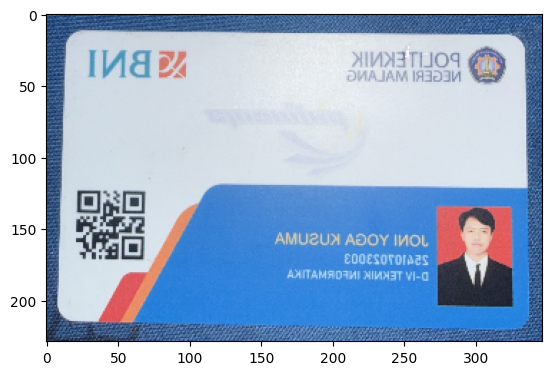

In [ ]:
citra_mirror = cv.flip(citra_kecil, 1)
plt.imshow(citra_mirror)


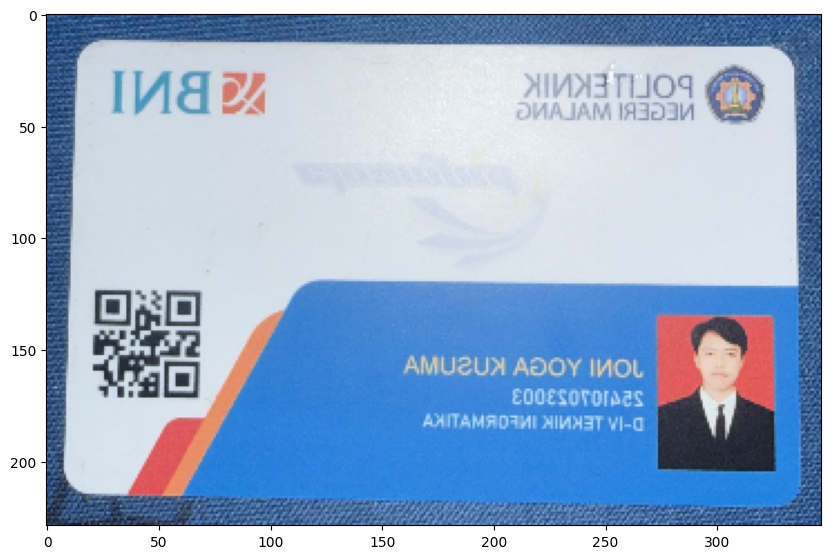

In [ ]:
citra_mirror = cv.flip(citra_kecil, 1)
plt.figure(figsize=(10, 10))
plt.imshow(citra_mirror)


## 6. Pembuatan bentuk geometri 2D menggunakan OpenCV dimulai dengan membuat citra berwarna hitam yang menggunakan tipe data int16

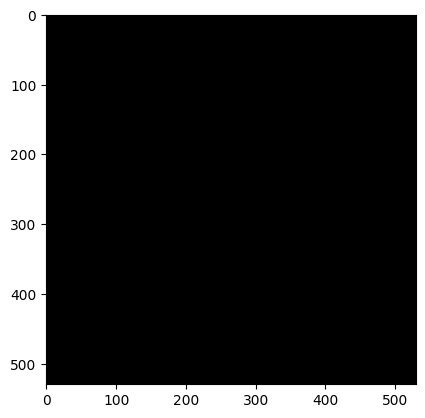

In [ ]:
kanvas = np.zeros((530, 530, 3), dtype=np.int16)
plt.imshow(kanvas)


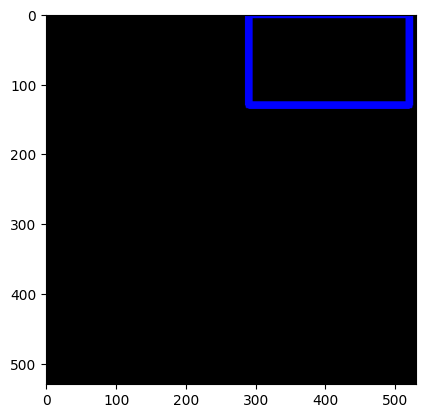

In [ ]:
cv.rectangle(kanvas, (290, 0), (520, 130), (0, 0, 255), 10)
plt.imshow(kanvas)


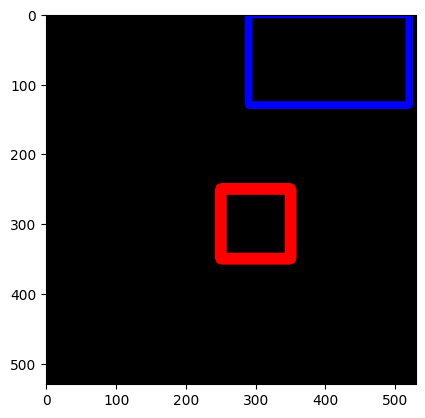

In [ ]:
cv.rectangle(kanvas, (250, 250), (350, 350), (255, 0, 0), 15)
plt.imshow(kanvas)


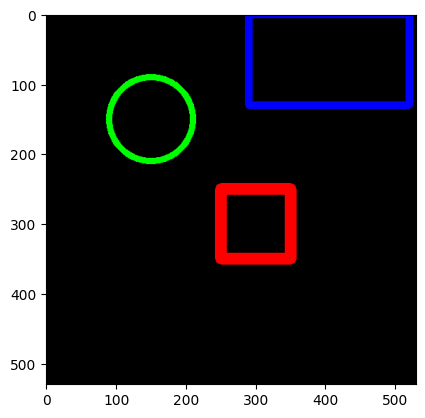

In [ ]:
cv.circle(kanvas, (150, 150), 60, (0, 255, 0), 8)
plt.imshow(kanvas)


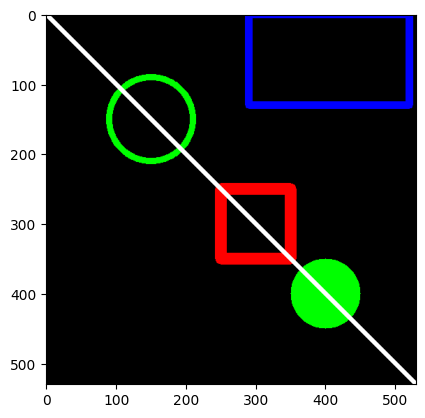

In [ ]:
cv.circle(kanvas, (400, 400), 50, (0, 255, 0), -1)
cv.line(kanvas, (0, 0), (530, 530), (255, 255, 255), 5)
plt.imshow(kanvas)


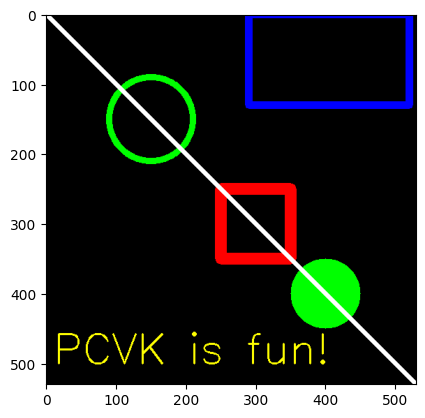

In [ ]:
cv.putText(
    kanvas, "PCVK is fun!", (10, 500),
    cv.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 0), 2, cv.LINE_AA,
)
plt.imshow(kanvas)


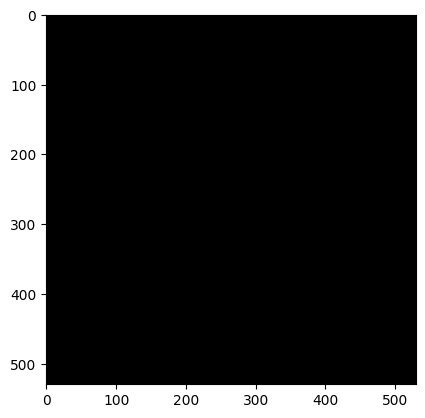

In [ ]:
kanvas2 = np.zeros((530, 530, 3), dtype=np.int32)
plt.imshow(kanvas2)


In [ ]:
titik = np.array([[150, 350], [250, 250], [450, 350], [250, 450]], dtype=np.int32)
titik


array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [ ]:
bentuk = titik.reshape((-1, 1, 2))
bentuk


array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

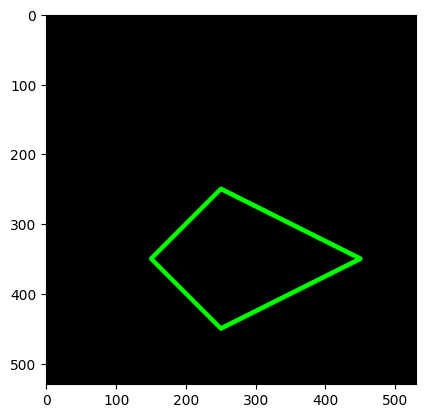

In [ ]:
cv.polylines(kanvas2, [bentuk], True, (0, 255, 0), 5)
plt.imshow(kanvas2)




---


# PERTANYAAN PRAKTIKUM

SOAL:

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.
3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?
4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.
5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

JAWAB:

1. Bedanya di cara baca warna. `cv2_imshow` menganggap datanya BGR, `plt.imshow` menganggap RGB. Array-nya bisa sama, tapi merah dan biru kelihatan tertukar. Kalau dibaca ulang dengan `skimage`, nilai R dan B-nya memang terbalik dibanding `cv.imread`.

2. Tampilan sama (hitam). `min` dan `max` sama-sama 0. `dtype` beda. `nbytes` int32 dua kali int16 karena tiap angka 4 byte, bukan 2 byte.

3. `cv2_imshow` itu versi Colab untuk menampilkan gambar di output sel. `cv.imshow` tidak jalan di Colab karena butuh jendela desktop, sementara Colab cuma browser.

4. Keduanya RGB, jadi warnanya benar. Yang kanalnya tertukar adalah hasil `cv.imread` kalau langsung di-`plt.imshow`. Bukti: piksel `io.imread` sama dengan hasil `COLOR_BGR2RGB`, dan kanal 0/2-nya kebalikan dari `cv.imread`.

5. Tidak berubah. `figsize` cuma memperbesar jendela plot. `img.shape` baru berubah kalau datanya diubah, misalnya pakai `cv.resize()`.


In [ ]:
# Soal 1: tampilkan TANPA konversi, lalu cetak piksel dari 2 cara baca
bgr = cv.imread('/content/KTM.jpg')
rgb_sk = io.imread('/content/KTM.jpg')
y, x = 40, 40

print("=== Soal 1 ===")
print("cv.imread :", bgr[y, x])
print("io.imread :", rgb_sk[y, x][:3])
print("cv2_imshow tanpa konversi:")
cv2_imshow(bgr)
print("plt.imshow tanpa konversi:")
plt.imshow(bgr)
plt.title("plt.imshow tanpa konversi")
plt.show()

# Soal 4: skimage vs hasil BGR2RGB, plus nilai piksel
rgb_cv = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
print("=== Soal 4 ===")
print("skimage         :", rgb_sk[y, x][:3])
print("OpenCV BGR2RGB  :", rgb_cv[y, x])

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(rgb_sk)
ax[0].set_title("skimage.io.imread")
ax[0].axis("off")
ax[1].imshow(rgb_cv)
ax[1].set_title("cvtColor BGR2RGB")
ax[1].axis("off")
plt.show()

# Soal 5: figsize besar, cek shape
print("=== Soal 5 ===")
print("shape sebelum figsize:", bgr.shape)
plt.figure(figsize=(14, 10))
plt.imshow(rgb_cv)
plt.title("figsize jauh lebih besar")
plt.show()
print("shape sesudah figsize:", bgr.shape)




---


# TUGAS PRAKTIKUM - Penerapan

## 1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.

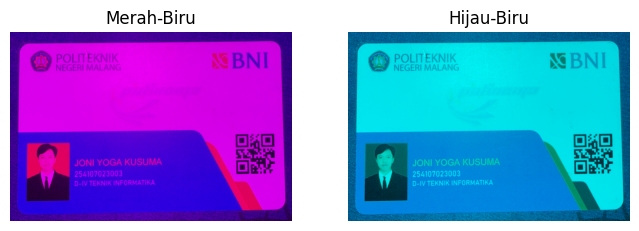

In [ ]:
rgb = citra[:, :, ::-1].copy()

hanya_rb = rgb.copy()
hanya_rb[..., 1] = 0

hanya_gb = rgb.copy()
hanya_gb[..., 0] = 0

fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(8, 4))
kiri.imshow(hanya_rb)
kiri.set_title("Merah-Biru")
kiri.axis("off")
kanan.imshow(hanya_gb)
kanan.set_title("Hijau-Biru")
kanan.axis("off")
plt.show()


## 2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

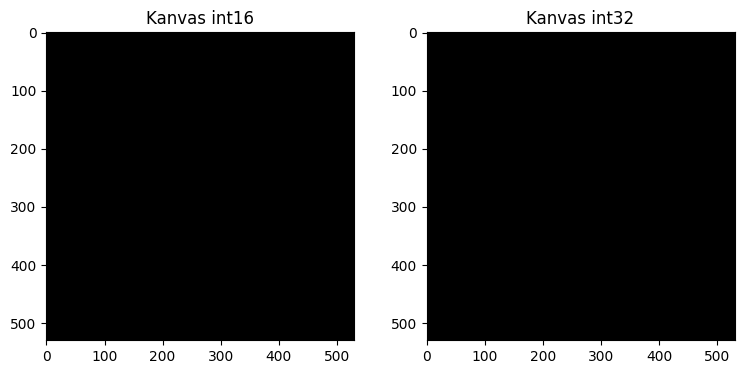

In [ ]:
ukur = (530, 530, 3)
kanvas16 = np.zeros(ukur, dtype=np.int16)
kanvas32 = np.zeros(ukur, dtype=np.int32)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(kanvas16)
ax[0].set_title("Kanvas int16")
ax[1].imshow(kanvas32)
ax[1].set_title("Kanvas int32")
plt.show()


Cek atribut kedua kanvas


In [ ]:
for nama, arr in [("int16", kanvas16), ("int32", kanvas32)]:
    print(nama, "-> dtype:", arr.dtype, "| min:", arr.min(), "| max:", arr.max(), "| nbytes:", arr.nbytes)


int16 -> dtype: int16 | min: 0 | max: 0 | nbytes: 1685400
int32 -> dtype: int32 | min: 0 | max: 0 | nbytes: 3370800


**Penjelasan:** Tampilan sama karena isinya nol semua (hitam). `min`/`max` = 0. Memori beda: int32 = 2× int16. `dtype` hanya menandai lebar bit tiap elemen.


## 3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Me.jpg to Me.jpg


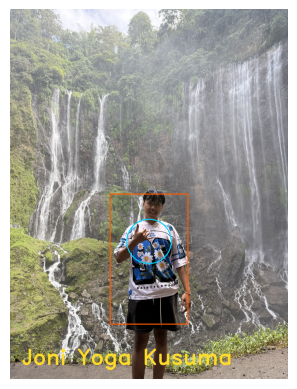

In [ ]:
foto = cv.imread('/content/Me.jpg')
foto = foto[:, :, ::-1].copy()
tinggi, lebar = foto.shape[:2]

# posisi orang: tengah, agak bawah
cx = lebar // 2
cy = int(tinggi * 0.66)
kotak_w = int(lebar * 0.14)
kotak_h = int(tinggi * 0.16)
tebal = max(10, lebar // 280)

cv.rectangle(
    foto,
    (cx - kotak_w, cy - kotak_h),
    (cx + kotak_w, cy + int(kotak_h * 1.2)),
    (255, 90, 0),
    tebal,
)
cv.circle(foto, (cx, cy - kotak_h // 5), int(lebar * 0.08), (0, 210, 255), tebal)

skala = lebar / 400
cv.putText(
    foto, "Joni Yoga Kusuma",
    (int(lebar * 0.04), int(tinggi * 0.96)),
    cv.FONT_HERSHEY_DUPLEX,
    skala,
    (255, 220, 40),
    max(10, int(skala * 2.4)),
    cv.LINE_AA,
)
plt.imshow(foto)
plt.axis("off")
plt.show()




---

# TUGAS PRAKTIKUM - Analisa

Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

**Pertanyaan**

Berapa persen piksel foto KTM yang intensitas grayscale-nya lebih kecil dari rata-rata?

**Rancangan**

1. Baca KTM sebagai grayscale.
2. Hitung rata-rata intensitas.
3. Hitung proporsi piksel < rata-rata, lalu jadikan persen.

**Data hasil**

Nilai rata-rata dan persentasenya tercetak di sel kode berikut.


In [3]:
ktm_abu = cv.imread('/content/KTM.jpg', cv.IMREAD_GRAYSCALE)
nilai_rata = float(ktm_abu.mean())
persen_gelap = (ktm_abu < nilai_rata).mean() * 100

print("Rata-rata intensitas:", round(nilai_rata, 2))
print("Piksel di bawah rata-rata:", round(persen_gelap, 2), "%")


Rata-rata intensitas: 164.51
Piksel di bawah rata-rata: 49.52 %


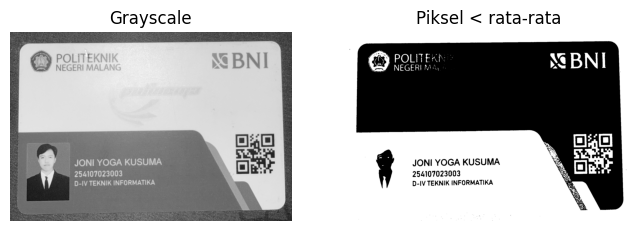

In [ ]:
mask_gelap = ktm_abu < nilai_rata

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(ktm_abu, cmap="gray")
ax[0].set_title("Grayscale")
ax[0].axis("off")
ax[1].imshow(mask_gelap, cmap="gray")
ax[1].set_title("Piksel < rata-rata")
ax[1].axis("off")
plt.show()


**Kesimpulan**

Persentase di bawah rata-rata tidak otomatis 50%. Kalau histogram foto tidak simetris (banyak area terang atau gelap), nilainya bergeser. Angka pastinya ada di output sel kode.


---




---
# TUGAS PRAKTIKUM - Aplikasi


## Studi Kasus 1

Tempel label teks di bawah citra. Tinggi bar = 1/12 tinggi gambar. Diuji pada foto landscape dan potret.


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np


In [5]:
from google.colab import files
uploaded = files.upload()

Saving bahlil.jpg to bahlil.jpg


In [6]:
def baca_rgb(path):
    data = cv.imread(path)
    return cv.cvtColor(data, cv.COLOR_BGR2RGB)


def tempel_label(path, teks="Dokumentasi PCVK - 2026"):
    hasil = baca_rgb(path).copy()
    h, w = hasil.shape[:2]
    tinggi_bar = max(h // 12, 16)
    cv.rectangle(hasil, (0, h - tinggi_bar), (w, h), (0, 0, 0), -1)
    cv.putText(
        hasil, teks,
        (w // 40, h - tinggi_bar // 3),
        cv.FONT_HERSHEY_SIMPLEX,
        tinggi_bar / 80,
        (255, 255, 255),
        max(2, tinggi_bar // 20),
        cv.LINE_AA,
    )
    return hasil


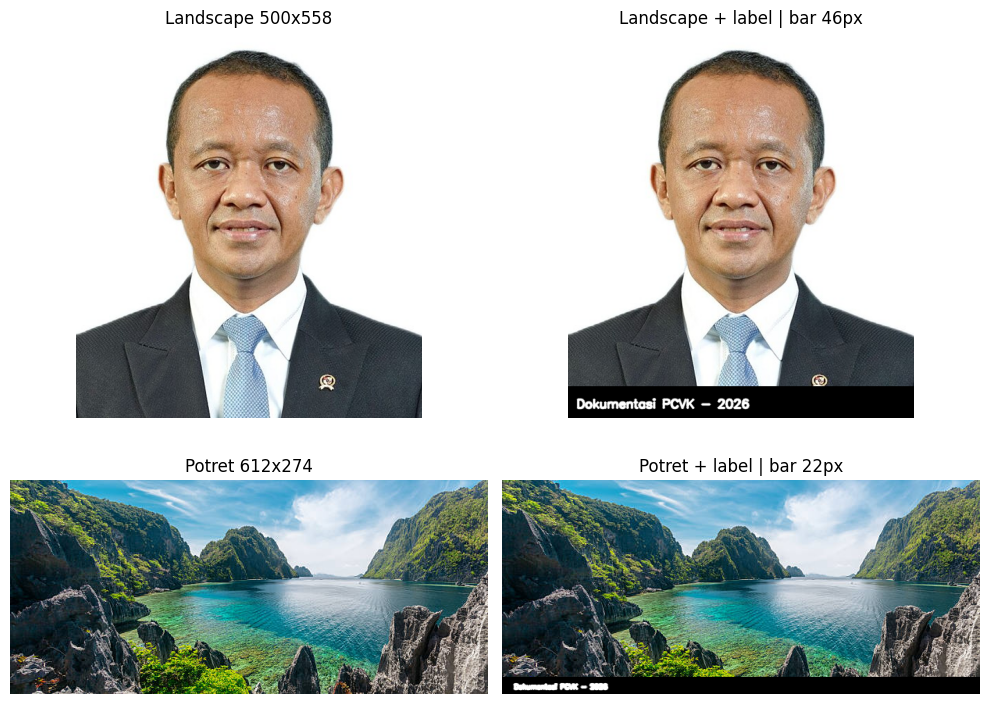

In [13]:
file_a = "/content/bahlil.jpg"
file_b = "/content/land.jpg"
paket = [(baca_rgb(file_a), tempel_label(file_a)), (baca_rgb(file_b), tempel_label(file_b))]
judul = ["Landscape", "Landscape + label", "Potret", "Potret + label"]

fig, grid = plt.subplots(2, 2, figsize=(10, 8))
for i, (asli, berlabel) in enumerate(paket):
    grid[i, 0].imshow(asli)
    grid[i, 0].set_title(f"{judul[i*2]} {asli.shape[1]}x{asli.shape[0]}")
    grid[i, 0].axis("off")
    grid[i, 1].imshow(berlabel)
    grid[i, 1].set_title(f"{judul[i*2+1]} | bar {berlabel.shape[0]//12}px")
    grid[i, 1].axis("off")
plt.tight_layout()
plt.show()


## Studi Kasus 2

Ubah citra jadi foto profil persegi: kanvas putih, sisi = sisi terpanjang, foto tetap rasio asli dan ditaruh di tengah. Diuji pada landscape dan potret.


In [8]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np


In [9]:
from google.colab import files
uploaded = files.upload()

In [10]:
def baca_rgb(path):
    data = cv.imread(path)
    return cv.cvtColor(data, cv.COLOR_BGR2RGB)


def pad_jadi_kotak(path):
    foto = baca_rgb(path)
    h, w = foto.shape[:2]
    sisi = max(h, w)
    alas = np.full((sisi, sisi, 3), 255, dtype=np.uint8)
    atas = (sisi - h) // 2
    kiri = (sisi - w) // 2
    alas[atas:atas + h, kiri:kiri + w] = foto
    return foto, alas


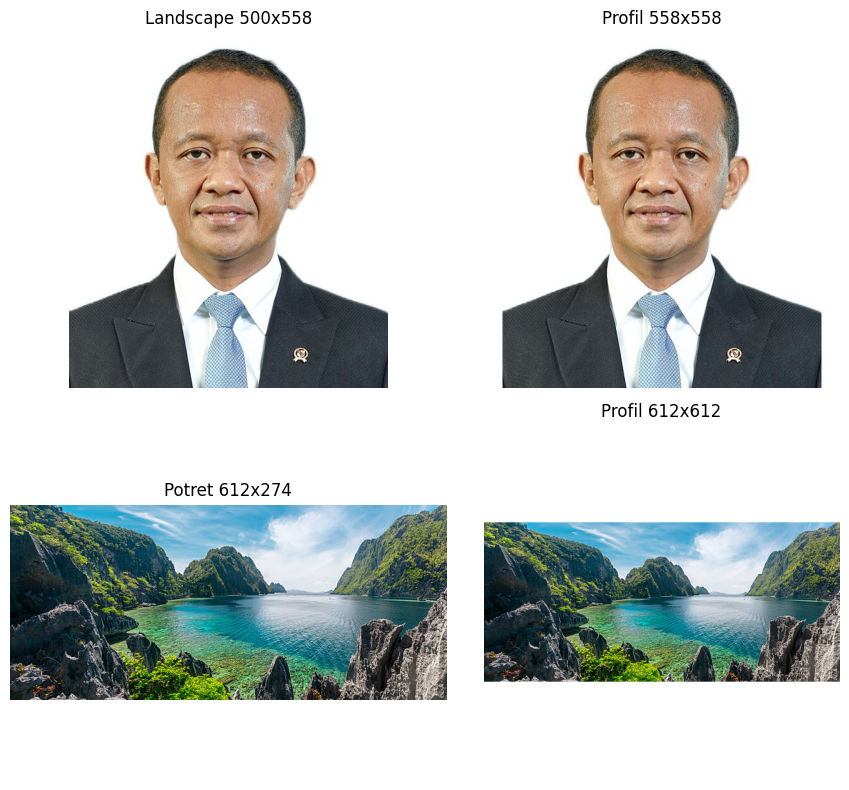

In [12]:
uji = [("/content/bahlil.jpg", "Landscape"), ("/content/land.jpg", "Potret")]

fig, ax = plt.subplots(2, 2, figsize=(9, 8))
for i, (path, nama) in enumerate(uji):
    asli, kotak = pad_jadi_kotak(path)
    ax[i, 0].imshow(asli)
    ax[i, 0].set_title(f"{nama} {asli.shape[1]}x{asli.shape[0]}")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(kotak)
    ax[i, 1].set_title(f"Profil {kotak.shape[0]}x{kotak.shape[1]}")
    ax[i, 1].axis("off")
plt.tight_layout()
plt.show()
